# Parameters

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy.integrate import solve_ivp

# Define time span and points for the simulation
TIME_END = 150.0
t_span = [0, TIME_END]
t_points = np.linspace(t_span[0], t_span[1], 1000)

# --- INITIAL CONCENTRATIONS (STATE VARIABLES) ---
# (M1, M2, IL1, IL12, IL10, IL4, Aq, Ap, D)

M1_0 = 0.1
M2_0 = 0.1

IL1_0  = 0.1
IL12_0 = 0.01
IL10_0 = 0.1
IL4_0  = 0.01

Aq_0 = 0.05
Ap_0 = 0.005

D_0 = 0.0

y0 = [M1_0, M2_0, IL1_0, IL12_0, IL10_0, IL4_0, Aq_0, Ap_0, D_0]

# --- MODEL PARAMETERS (CONSTANTS) ---

# Parameters from Rm1 
k_n1   = 1.23121468628907
k_n12  = 1.3444424885940314
x_n    = 2.47585316397624
b_n    = 0.8682932268535773
a_inf1 = 2.944948653936038

# Parameters from Rm2 
k_n4  = 1.272493506699988
k_n10 = 0.8577380244036067
z_n   = 2.3786552539888537
y_n   = 0.9996433532137823

# Parameters from mr 
s_mr  = 1.0960359353301747
mu_mr = 0.36232256985896183

# Parameters from Rms 
tau_n4  = 1.1705406202322937
tau_n10 = 0.9048457485245999
g_n     = 2.464228895378905
m_n     = 0.563495322717254

# Parameters from Rp 
k_M1base = 0.9926354332956264
kcd      = 1.202623143443761
h_n      = 2.493063875169106
v_n      = 1.6633392059433056
a_inf2   = 1.651861798448556         # Also used in Ra and dD/dt

# Parameters from dIL1/dt
k_pn1 = 2.00487443066468
mu_n1 = 0.31766812384668947

# Parameters from dIL12/dt 
k_pn12 = 20.659169915759403
mu_n12 = 0.20508819119658298

# Parameters from Rt 
k_tbase = 0.947187881552978
k_tn12  = 1.0707050213093836
c_n     = 2.661117852785608
r_n     = 1.6774534754063852

# Parameters from Ra 
k_M2base = 0.9707774602596897
kc4      = 0.9238073930606325
q_n      = 2.3567649771794734
w_n      = 0.9997073991548225

# Parameters from dIL10/dt 
k_tn10 = 1.2260936900650916
k_pn10 = 1.2436568657494924
mu_n10 = 0.47020795161687023

# Parameters from dIL4/dt 
k_tn4 = 0.9546207188594067
k_pn4 = 0.9803768557089533
mu_n4 = 0.30439335856121924

# Parameters from dD/dt 
alpha_n12 = 1.1383684645435397
alpha_n1  = 1.1915264432034482
r_M1      = 0.26862120846959575
gamma_M1  = 0.38999592743353073
gamma_M2  = 0.5308181970140535
mu_M1     = 0.09685420836766151
mu_M2     = 0.08041242746608893

# Astroglia dynamics parameters
k_Aq_M2 = 0.3      # M2 promotes Aq (neuroprotective)
k_Ap_M1 = 0.8      # M1 promotes Ap proliferation
k_Ap_D  = 0.6      # Damage/Aβ promotes Ap proliferation
k_Aq2Ap = 0.4      # Aq → Ap conversion rate (inflammation-driven)
k_Ap2Aq = 0.2      # Ap → Aq conversion rate (resolution)
mu_Aq   = 0.05     # Aq death/removal rate
mu_Ap   = 0.08     # Ap death/removal rate
s_Aq    = 0.1      # Aq baseline production

# Astroglia feedback on microglia (from Puri & Li Figure 1)
beta_Aq_M2 = 0.5   # Aq promotes M2 (helps maintain anti-inflammatory state)
beta_Ap_M1 = 0.4   # Ap promotes M1 (positive feedback for inflammation)
beta_Aq_inhib_M1 = 0.3  # Aq inhibits M1

# Astroglia effect on damage/repair
psi_Aq = 0.3       # Aq helps with damage clearance/repair
psi_Ap = 0.2       # Ap can contribute to damage (gliosis)

# --- ROS-Related Parameters ---
p_ros = 1.0    # Influence of ROS on M1 (strength of pro-inflammatory shift)
i_ros = 10    # Influence of ROS on M2 (strength of suppression)

# INDEPENDENT VARIABLE
ROS = 100.0


params = {
    'k_n1': k_n1,
    'k_n12': k_n12,
    'x_n': x_n,
    'b_n': b_n,
    'a_inf1': a_inf1,
    'k_n4': k_n4,
    'k_n10': k_n10,
    'z_n': z_n,
    'y_n': y_n,
    's_mr': s_mr,
    'mu_mr': mu_mr,
    'tau_n4': tau_n4,
    'tau_n10': tau_n10,
    'g_n': g_n,
    'm_n': m_n,
    'k_M1base': k_M1base,
    'kcd': kcd,
    'h_n': h_n,
    'v_n': v_n,
    'a_inf2': a_inf2,
    'k_pn1': k_pn1,
    'mu_n1': mu_n1,
    'k_pn12': k_pn12,
    'mu_n12': mu_n12,
    'k_tbase': k_tbase,
    'k_tn12': k_tn12,
    'c_n': c_n,
    'r_n': r_n,
    'k_M2base': k_M2base,
    'kc4': kc4,
    'q_n': q_n,
    'w_n': w_n,
    'k_tn10': k_tn10,
    'k_pn10': k_pn10,
    'mu_n10': mu_n10,
    'k_tn4': k_tn4,
    'k_pn4': k_pn4,
    'mu_n4': mu_n4,
    'alpha_n12': alpha_n12,
    'alpha_n1': alpha_n1,
    'r_M1': r_M1,
    'gamma_M1': gamma_M1,
    'gamma_M2': gamma_M2,
    'mu_M1': mu_M1,
    'mu_M2': mu_M2,
    'k_Aq_M2':k_Aq_M2,
    'k_Ap_M1':k_Ap_M1,
    'k_Ap_D':k_Ap_D,
    'k_Aq2Ap':k_Aq2Ap,
    'k_Ap2Aq':k_Ap2Aq,
    'mu_Aq':mu_Aq,
    'mu_Ap':mu_Ap,
    's_Aq':s_Aq,
    'beta_Aq_M2':beta_Aq_M2,
    'beta_Ap_M1':beta_Ap_M1,
    'beta_Aq_inhib_M1':beta_Aq_inhib_M1,
    'psi_Aq':psi_Aq,
    'psi_Ap':psi_Ap,
    'ROS': ROS,
    'p_ros': p_ros,
    'i_ros': i_ros
}

# Rm equations

Terms Rm1 and Rm2 describe cytokine-based cues for the activation of resting microglia into M1 and M2 microglia, respectively.


## Rm1 term
$$ Rm1 = \frac{\displaystyle  \frac{(k_{n1} \cdot IL1\beta + k_{n12} \cdot IL12)^{x_n}}{b_{n}^{x_n} + (k_{n1} \cdot IL1\beta + k_{n12} \cdot IL12)^{x_n}}}{1 + \left(\displaystyle \frac{IL10 + IL4}{a_{\infty 1}}\right)^2}.$$

For the incorporation of astroglia feedback, the assumption that Rm1 (M1 recruitment) is enhanced by $A_p$ (proliferating astroglia) and inhibited by $A_q$ (quiescent astroglia) is applied.

$$Rm1_{astroglia} = Rm1 \cdot \left[ \frac{1 + \beta_{Ap\_M1} \cdot A_p}{1 + \beta_{Aq\_inhib\_M1} \cdot A_q} \right],$$
with $\left[ \frac{1 + \beta_{Ap\_M1} \cdot A_p}{1 + \beta_{Aq\_inhib\_M1} \cdot A_q} \right]$ serving as an Astroglia Modulating Factor. 

This factor ensures:
- Enhancement: If $\mathbf{A_p}$ is high and $\mathbf{A_q}$ is low, $F_{Astroglia} > 1$, increasing the $\mathbf{Rm1}$ rate.
- Inhibition: If $\mathbf{A_p}$ is low and $\mathbf{A_q}$ is high, $F_{Astroglia} < 1$, decreasing the $\mathbf{Rm1}$ rate.
- No Effect: If $\mathbf{A_p}$ and $\mathbf{A_q}$ are both zero (no astroglia in the model), $F_{Astroglia} = 1$, and the original equation is recovered.

In [2]:
def calculate_rm1(IL1, IL12, IL4, IL10, Ap, Aq, *, b_n, x_n, a_inf1, k_n1, k_n12,beta_Ap_M1,beta_Aq_inhib_M1):
    
    A = max(k_n1 * IL1 + k_n12 * IL12, 0.0)**x_n
    B = b_n**x_n + A
    C = 1 + ((IL10 + IL4) / a_inf1)**2

    # Astroglia interaction
    rm1_microglia = A / (B * C)
    FA_M1 = (1 + beta_Ap_M1 * Ap) / (1 + beta_Aq_inhib_M1 * Aq) # Astroglia modulating factor

    return rm1_microglia * FA_M1

## Rm2 term

$$Rm2 = \frac{(k_{n4} \cdot IL4 + k_{n10} \cdot IL10)^{z_n}}{y_{n}^{z_n} + (k_{n4} \cdot IL4 + k_{n10} \cdot IL10)^{z_n}}$$

For anti-inflammatory state function, similar to $\mathbf{Rm1}$, an astroglia modulating factor is utilized, however only the role of Quiescent Astroglia ($\mathbf{A_q}$) promoting $\mathbf{M2}$ recruitment, for assistance in maintaining anti-inflammatory states.

$$Rm2_{astroglia} = Rm2 \cdot (1 + \beta_{Aq\_M2} \cdot A_q)$$

In [3]:
def calculate_rm2(IL4, IL10, Aq, *, y_n, z_n, k_n4, k_n10, beta_Aq_M2):

    A = max(k_n4 * IL4 + k_n10 * IL10, 0.0)**z_n
    B = y_n**z_n + A

    rm2_microglia = A / B
    FA_M2 = 1 + beta_Aq_M2 * Aq

    return rm2_microglia * FA_M2

# mr term

Microglial production is presumed as a steady state within the model with the following equation demonstrating the approximation

$$mr \approx \frac{s_{mr}}{Rm1 + Rm2 + \mu_{mr}}  $$

In [4]:
def calculate_mr(Rm1, Rm2, *, s_mr, mu_mr):
    
    numerator = s_mr
    denominator = Rm1 + Rm2 + mu_mr
    
    return numerator / denominator

# Rms term

Hill function to represent contributions of anti-inflammatory mediation by IL-4 and IL-10 toward shifting neurotoxic M1 microglia into a neuroprotective and reparative M2 microglia

$$ Rms = \frac{(\tau_{n4} \cdot IL4 + \tau_{n10} \cdot IL10)^{g_n}}{m_{n}^{g_n} + (\tau_{n4} \cdot IL4 + \tau_{n10} \cdot IL10)^{g_n}} $$

In [5]:
def calculate_rms(IL4, IL10, *, tau_n4, tau_n10, g_n, m_n):
    
    common_term = tau_n4 * IL4 + tau_n10 * IL10
    
    numerator = max(common_term, 0.0)**g_n
    denominator = max(m_n, 0.0)**g_n + numerator
    
    return numerator / denominator

# M1 Equation

$$ \frac{dM_1}{dt}
= Rm1 \cdot mr (1 + p_{\text{ros}} \cdot ROS) - (Rms + \mu_{M1}) \cdot M_1 $$

In [6]:
def calculate_dM1_dt(Rm1, mr, Rms, M1, r_M1, gamma_M1, alpha_n1, mu_M1, ROS, p_ros):
   
    production = Rm1 * mr * (1 + p_ros * ROS)
    
    removal_conversion = Rms * M1 + mu_M1 * M1
    
    return production - removal_conversion

# M2 Equation

$$ \frac{dM2}{dt} = Rm2 \cdot mr (1 - i_{\text{ros}} \cdot ROS) + Rms \cdot M1 - \mu_{M2} \cdot M2 $$

In [7]:
def calculate_dM2_dt(Rm2, mr, Rms, M1, M2, gamma_M2, mu_M2, ROS, i_ros):
   
    production_conversion = Rm2 * mr * max(0.0, 1 - i_ros * ROS) + Rms * M1
    
    degradation = mu_M2 * M2
    
    return production_conversion - degradation

# Rp term

M1 microglia are the major agents of pro-inflammatory cytokine secretion within the model, with a release rate described using the term Rp

$$ Rp = \frac{k_{M1base} \cdot M1 + M1 \left(\displaystyle \frac{(IL12 + kcd \cdot D)^{h_n}}{v_{n}^{h_n} + (IL12 + kcd \cdot D)^{h_n}}\right)}{1 + \left(\displaystyle\frac{IL10 + IL4}{a_{\infty 1}}\right)^2}$$

In [8]:
def calculate_Rp(M1, IL12, D, IL10, IL4, *, k_M1base, kcd, h_n, v_n, a_inf1):
    
    # --- Activation function ---
    activation_common_term = max(IL12 + kcd * D, 0.0)  # Clip to prevent negative values
    activation_num = activation_common_term**h_n
    activation_den = v_n**h_n + activation_common_term**h_n
    activation_function = activation_num / activation_den
    
    # Numerator
    term1 = k_M1base * max(M1, 0.0)
    term2 = max(M1, 0.0) * activation_function
    numerator = term1 + term2
    
    # Denominator
    inhibition_term = max(IL10 + IL4, 0.0) / a_inf1
    denominator = 1 + inhibition_term**2
    
    return numerator / denominator

# The release rates of pro-inflammatory cytokines IL-1β

$$ \frac{dIL1\beta}{dt} = k_{pn1} \cdot Rp - \mu_{n1} \cdot IL1\beta $$

In [9]:
def calculate_dIL1_dt(Rp, IL1, k_pn1, mu_n1):
   
    production = k_pn1 * Rp
    
    degradation = mu_n1 * IL1
    
    return production - degradation

# The release rates of pro-inflammatory cytokines IL-12

$$\frac{dIL12}{dt} = k_{pn12} \cdot Rp - \mu_{n12} \cdot IL12 $$

In [10]:
def calculate_dIL12_dt(Rp, IL12, *, k_pn12, mu_n12):
   
    # Production term
    production = k_pn12 * Rp
    
    # Degradation term
    degradation = mu_n12 * IL12
    
    return production - degradation

# Rt term

Accounts for indirect influences of Type 2 Th (Th2) cells on the production of IL-4 and IL-10

$$ Rt = \frac{k_{tbase} + \left(\displaystyle\frac{(IL4 + k_{tn12} \cdot IL12)^{c_n}}{r_{n}^{c_n} + (IL4 + k_{tn12} \cdot IL12)^{c_n}}\right)}{1 + \left(\displaystyle\frac{IL10}{a_{\infty 2}}\right)^2} $$

In [11]:
def calculate_Rt(IL4, IL12, IL10, *, k_tbase, k_tn12, c_n, r_n, a_inf2):

    r_n = max(r_n, 0.0)

    # --- Regulatory function ---
    reg_common_term = max(IL4 + k_tn12 * IL12, 0.0)
    reg_num = reg_common_term**c_n
    reg_den = r_n**c_n + reg_num
    regulatory_function = reg_num / reg_den
    
    # Numerator
    numerator = k_tbase + regulatory_function
    
    # Denominator
    inhibition_term = IL10 / a_inf2
    denominator = 1 + inhibition_term**2
    
    return numerator / denominator

# Ra term

Rate of synthesis and secretion of anti-inflammatory cytokines by M2 microglia

$$Ra = \frac{k_{M2base} \cdot M2 + M2 \left(\displaystyle\frac{(kc4 \cdot IL4)^{q_n}}{w_{n}^{q_n} + (kc4 \cdot IL4)^{q_n}}\right)}{1 + \left(\displaystyle \frac{IL10}{a_{\infty 2}}\right)^2} $$

In [12]:
def calculate_Ra(M2, IL4, IL10, *, k_M2base, kc4, q_n, w_n, a_inf2):
    
    w_n = max(w_n, 0.0)
    
    # --- Regulatory function ---
    reg_common_term = max(kc4 * IL4, 0.0)
    reg_num = reg_common_term**q_n
    reg_den = w_n**q_n + reg_num
    regulatory_function = reg_num / reg_den
    
    # Numerator
    numerator = k_M2base * M2 + M2 * regulatory_function
    
    # Denominator
    inhibition_term = IL10 / a_inf2
    denominator = 1 + inhibition_term**2
    
    return numerator / denominator

# Equation for IL-10

IL-10 suppresses T cell responses and, in turn, its own production

$$\frac{dIL10}{dt} = k_{tn10} \cdot Rt + k_{pn10} \cdot Ra - \mu_{n10} \cdot IL10 $$

In [13]:
def calculate_dIL10_dt(Rt, Ra, IL10, *, k_tn10, k_pn10, mu_n10):
    
    # Production terms
    production = k_tn10 * Rt + k_pn10 * Ra
    
    # Degradation term
    degradation = mu_n10 * IL10
    
    return production - degradation

# Equation for IL-4

IL-4 serves the dual role of driving additional microglial polarization toward M2 polarization and inducing anti-inflammatory cytokine production

$$\frac{dIL4}{dt} = k_{tn4} \cdot Rt + k_{pn4} \cdot Ra - \mu_{n4} \cdot IL4 $$


In [14]:
def calculate_dIL4_dt(Rt, Ra, IL4, *, k_tn4, k_pn4, mu_n4):

    # Production terms
    production = k_tn4 * Rt + k_pn4 * Ra
    
    # Degradation term
    degradation = mu_n4 * IL4
    
    return production - degradation

# Astroglia Dynamics

Conversion Terms (Rate Definitions)
    $$\mathbf{Aq\_to\_Ap} = \mathbf{k_{Aq2Ap}} \cdot A_q \cdot (k_{Ap\_M1} \cdot M1 + k_{Ap\_D} \cdot D)$$$$\mathbf{Ap\_to\_Aq} = \mathbf{k_{Ap2Aq}} \cdot A_p \cdot M2$$

Quiescent Astroglia ($\mathbf{A_q}$) Dynamics
   $$\mathbf{\frac{d A_q}{dt}} = \underbrace{s_{Aq}}_{\text{Baseline Source}} + \underbrace{\mathbf{k_{Aq\_M2} \cdot M2}}_{\text{M2-driven Production}} + \underbrace{\mathbf{Ap\_to\_Aq}}_{\text{Resolution Source}} - \underbrace{\mathbf{Aq\_to\_Ap}}_{\text{Activation Sink}} - \underbrace{\mu_{Aq} \cdot A_q}_{\text{Death/Removal Sink}}$$

In [15]:
def calculate_dAq_dt(Aq, Ap, M1, M2, D, *, s_Aq, k_Aq_M2, k_Ap2Aq, k_Aq2Ap, k_Ap_M1, k_Ap_D, mu_Aq):

    # 1. Conversion of Aq to Ap (Driven by M1 and D)
    Aq_to_Ap = k_Aq2Ap * Aq * (k_Ap_M1 * M1 + k_Ap_D * D)

    # 2. Conversion of Ap back to Aq (Driven by M2)
    Ap_to_Aq = k_Ap2Aq * Ap * M2

    # Sources of Aq:
    source_baseline = s_Aq
    source_M2_support = k_Aq_M2 * M2
    source_resolution = Ap_to_Aq

    # Sinks of Aq
    sink_activation = Aq_to_Ap
    sink_death = mu_Aq * Aq

    dAq_dt = source_baseline + source_M2_support + source_resolution - sink_activation - sink_death

    return dAq_dt

Proliferating Astroglia ($\mathbf{A_p}$) Dynamics$$\mathbf{\frac{d A_p}{dt}} = \underbrace{\mathbf{Aq\_to\_Ap}}_{\text{Activation Source}} - \underbrace{\mathbf{Ap\_to\_Aq}}_{\text{Resolution Sink}} - \underbrace{\mu_{Ap} \cdot A_p}_{\text{Death/Removal Sink}}$$

In [16]:
def calculate_dAp_dt(Aq, Ap, M1, M2, D, *, k_Ap2Aq, k_Aq2Ap, k_Ap_M1, k_Ap_D, mu_Ap):
    
    # 1. Conversion of Aq to Ap (Driven by M1 and D)
    Aq_to_Ap = k_Aq2Ap * Aq * (k_Ap_M1 * M1 + k_Ap_D * D)

    # 2. Conversion of Ap back to Aq (Driven by M2)
    Ap_to_Aq = k_Ap2Aq * Ap * M2

    # Sources of Ap:
    source_activation = Aq_to_Ap

    # Sinks of Ap:
    sink_resolution = Ap_to_Aq
    sink_death = mu_Ap * Ap

    dAp_dt = source_activation - sink_resolution - sink_death

    return dAp_dt

# Damage Signaling Dynamics

Represents a qualitative tissue damage level, serving as a proxy for long-term outcome among individuals with a neurodegenerative diseases

$$\frac{dD}{dt} = \underbrace{\frac{\alpha_{n12} \cdot IL12 + \alpha_{n1} \cdot IL1\beta}{1 + \left(\frac{IL10}{a_{\infty 2}}\right)^2} + r_{M1} \cdot M1}_{\text{Damage Production (from Cytokines/M1)}} - \underbrace{\gamma_{M1} \cdot M1 \cdot D - \gamma_{M2} \cdot M2 \cdot D}_{\text{Damage Clearance (M1/M2)}} + \underbrace{\mathbf{\psi_{Ap} \cdot A_p \cdot D}}_{\text{Ap Damage}}  - \underbrace{\mathbf{\psi_{Aq} \cdot A_q \cdot D}}_{\text{Aq Repair}}$$

In [17]:
def calculate_dD_dt(IL12, IL1, IL10, M1, D, M2, Ap, Aq, alpha_n12, alpha_n1, r_M1, gamma_M1, gamma_M2, a_inf2, psi_Ap, psi_Aq):

    a_inf2 = max(a_inf2, 1e-12)

    # IL-10–dependent inhibition term
    denominator = 1 + (IL10 / a_inf2)**2

    # Damage induced by IL12 and IL1 under IL10 inhibition
    damage_term = (alpha_n12 * IL12 + alpha_n1 * IL1) / denominator
    damage_production = damage_term + r_M1 * M1

    # Clearance by M1 and M2
    clearance_M1 = gamma_M1 * M1 * D
    clearance_M2 = gamma_M2 * M2 * D

    # Damage production - Damage clearance
    damage_terms = damage_production - clearance_M1 - clearance_M2

    # Astroglia damage production/repair
    astrocyte_damage = psi_Ap * Ap * D
    astrocyte_repair = psi_Aq * Aq * D

    return damage_terms + astrocyte_damage - astrocyte_repair

# ODE System Solver

In [18]:
def rhs_function(t, Y):
    """
    Calculates the vector of derivatives (dY/dt) by calling all previously 
    defined rate and differential equations. This function is passed to solve_ivp.
    """
    
    M1, M2, IL1, IL12, IL10, IL4, Aq, Ap, D = Y

    # --- Negative Prevention ---
    M1  = max(M1, 0.0)
    M2  = max(M2, 0.0)
    IL1  = max(IL1, 0.0)
    IL12 = max(IL12, 0.0)
    IL10 = max(IL10, 0.0)
    IL4  = max(IL4, 0.0)
    Aq   = max(Aq, 0.0)
    Ap   = max(Ap, 0.0)
    D    = max(D, 0.0)

    # --- Auxiliary Rates ---
    
    Rm1 = calculate_rm1(
        IL1, IL12, IL4, IL10, Ap, Aq,
        b_n=params['b_n'],
        x_n=params['x_n'],
        a_inf1=params['a_inf1'],
        k_n1=params['k_n1'],
        k_n12=params['k_n12'],
        beta_Ap_M1=params['beta_Ap_M1'],
        beta_Aq_inhib_M1=params['beta_Aq_inhib_M1']
    )
    
    Rm2 = calculate_rm2(
        IL4, IL10, Aq,
        y_n=params['y_n'],
        z_n=params['z_n'],
        k_n4=params['k_n4'],
        k_n10=params['k_n10'],
        beta_Aq_M2=params['beta_Aq_M2']
    )
    
    Rms = calculate_rms(
        IL4, IL10,
        tau_n4=params['tau_n4'],
        tau_n10=params['tau_n10'],
        g_n=params['g_n'],
        m_n=params['m_n']
    )
    
    mr = calculate_mr(
        Rm1, Rm2,
        s_mr=params['s_mr'],
        mu_mr=params['mu_mr']
    )
    
    Rp = calculate_Rp(
        M1, IL12, D, IL10, IL4,
        k_M1base=params['k_M1base'],
        kcd=params['kcd'],
        h_n=params['h_n'],
        v_n=params['v_n'],
        a_inf1=params['a_inf1']
    )

    Rt = calculate_Rt(
        IL4, IL12, IL10,
        k_tbase=params['k_tbase'],
        k_tn12=params['k_tn12'],
        c_n=params['c_n'],
        r_n=params['r_n'],
        a_inf2=params['a_inf2']
    )
    
    Ra = calculate_Ra(
        M2, IL4, IL10,
        k_M2base=params['k_M2base'],
        kc4=params['kc4'],
        q_n=params['q_n'],
        w_n=params['w_n'],
        a_inf2=params['a_inf2']
    )

    
    # --- Derivatives ---
    
    # dM1/dt and dM2/dt
    dM1_dt = calculate_dM1_dt(
        Rm1, mr, Rms, M1,
        r_M1=params['r_M1'],
        gamma_M1=params['gamma_M1'],
        alpha_n1=params['alpha_n1'],
        mu_M1=params['mu_M1'],
        ROS=params['ROS'],
        p_ros=params['p_ros']
    )
    
    dM2_dt = calculate_dM2_dt(
        Rm2, mr, Rms, M1, M2,
        gamma_M2=params['gamma_M2'],
        mu_M2=params['mu_M2'],
        ROS=params['ROS'],
        i_ros=params['i_ros']
    )
    
    # Cytokines (IL1, IL12, IL10, IL4)
    dIL1_dt = calculate_dIL1_dt(
        Rp, IL1,
        k_pn1=params['k_pn1'],
        mu_n1=params['mu_n1']
    )
    
    dIL12_dt = calculate_dIL12_dt(
        Rp, IL12,
        k_pn12=params['k_pn12'],
        mu_n12=params['mu_n12']
    )
    
    dIL10_dt = calculate_dIL10_dt(
        Rt, Ra, IL10,
        k_tn10=params['k_tn10'],
        k_pn10=params['k_pn10'],
        mu_n10=params['mu_n10']
    )
    
    dIL4_dt = calculate_dIL4_dt(
        Rt, Ra, IL4,
        k_tn4=params['k_tn4'],
        k_pn4=params['k_pn4'],
        mu_n4=params['mu_n4']
    )

    dAq_dt = calculate_dAq_dt(
        Aq, Ap, M1, M2, D, 
        s_Aq=params['s_Aq'], 
        k_Aq_M2=params['k_Aq_M2'], 
        k_Ap2Aq=params['k_Ap2Aq'], 
        k_Aq2Ap=params['k_Aq2Ap'], 
        k_Ap_M1=params['k_Ap_M1'], 
        k_Ap_D=params['k_Ap_D'], 
        mu_Aq=params['mu_Aq']
    )

    dAp_dt = calculate_dAp_dt(
        Aq, Ap, M1, M2, D, 
        k_Ap2Aq=params['k_Ap2Aq'], 
        k_Aq2Ap=params['k_Aq2Ap'],
        k_Ap_M1=params['k_Ap_M1'], 
        k_Ap_D=params['k_Ap_D'], 
        mu_Ap=params['mu_Ap']
    )
    
    # Damage Signal (D)
    dD_dt = calculate_dD_dt(
        IL12, IL1, IL10, M1, D, M2, Ap, Aq,
        alpha_n12=params['alpha_n12'],
        alpha_n1=params['alpha_n1'],
        r_M1=params['r_M1'],
        gamma_M1=params['gamma_M1'],
        gamma_M2=params['gamma_M2'],
        a_inf2=params['a_inf2'],
        psi_Ap=params['psi_Ap'], 
        psi_Aq=params['psi_Aq']
    ) 

        # --- Non-Negative Derivatives ---
    dM1_dt  = max(dM1_dt, -M1)
    dM2_dt  = max(dM2_dt, -M2)
    dIL1_dt  = max(dIL1_dt, -IL1)
    dIL12_dt = max(dIL12_dt, -IL12)
    dIL10_dt = max(dIL10_dt, -IL10)
    dIL4_dt  = max(dIL4_dt, -IL4)
    dAq_dt   = max(dAq_dt, -Aq)
    dAp_dt   = max(dAp_dt, -Ap)
    dD_dt    = max(dD_dt, -D)

    
    return np.array([
        dM1_dt, dM2_dt, dIL1_dt, dIL12_dt, dIL10_dt, dIL4_dt, dAq_dt, dAp_dt, dD_dt
    ])


# --- SOLVER SETUP AND EXECUTION ---

print("Starting ODE solver...")
solution = solve_ivp(
    fun=rhs_function,              # The function defining the system
    t_span=t_span,                 # Start and end time
    y0=y0,                         # Initial conditions vector
    t_eval=t_points,               # Specific time points to return
    method='RK45',                 # Runge-Kutta 4th Order (good default)
    rtol=1e-6, atol=1e-9           # Error tolerances
)
print("ODE solution complete.")

# --- BASIC RESULTS PROCESSING ---

if solution.success:
    results_df = pd.DataFrame({
        "Time": solution.t,
        "M1": solution.y[0],
        "M2": solution.y[1],
        "IL1": solution.y[2],
        "IL12": solution.y[3],
        "IL10": solution.y[4],
        "IL4": solution.y[5],
        "Aq": solution.y[6],
        "Ap": solution.y[7],
        "D": solution.y[8],
    })
    
    # Save all data to CSV
    results_df.to_csv("ode_full_output.csv", index=False)
    print("Full ODE output saved to ode_full_output.csv")

    import os
    os.getcwd()

    display(Markdown("### Simulation Results (First 5 Time Points)"))
    display(results_df.head())

else:
    print(f"Solver failed: {solution.message}")

Starting ODE solver...
ODE solution complete.
Full ODE output saved to ode_full_output.csv


### Simulation Results (First 5 Time Points)

,Time,M1,M2,IL1,IL12,IL10,IL4,Aq,Ap,D
0,0.000000,0.100000,0.100000,0.100000,0.010000,0.100000,0.010000,0.050000,0.005000,0.000000
1,0.150150,5929.967534,550.235693,826.782527,8606.717370,7.623971,5.998291,0.622760,9.377226,3.294715
2,0.300300,5733.575823,1430.260459,867.550049,9171.006662,14.480650,11.620606,7.503124,46.951373,2.835362
3,0.450450,4963.199625,2211.414992,856.047172,9193.587625,19.501726,15.897937,29.819758,106.112239,2.440052
4,0.600601,4271.224133,2872.567045,831.455886,9073.712838,23.463020,19.410964,73.864307,174.948998,2.099857


ROS sweep:   0%|          | 0/61 [00:00<?, ?it/s]

Results:
min_effective ROS (≥ 10% change): 0.01
saturation ROS (plateau threshold, < 1% changes onward): 100000.0
mid ROS chosen: 31.622776601683793


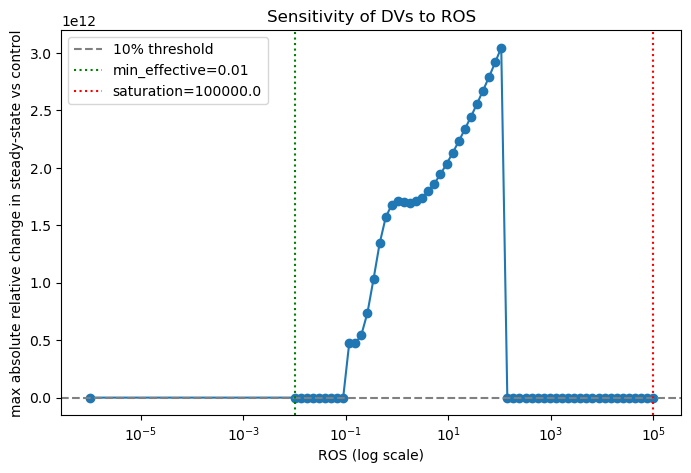

Selected ROS values for comparison (control, min, mid, saturation):
[0.0, 0.01, 31.622776601683793, 100000.0]


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm.notebook import tqdm

# ---------- User-tweakable thresholds ----------
min_change_tol = 0.10   # 10% relative change from control -> consider "effective"
sat_tol = 0.01          # 1% change beyond saturation -> consider "plateau"
last_fraction = 0.05    # fraction of final timepoints to average for steady-state
max_ros_allowed = 1e6   # safety cap to avoid nonsense values

# --- ROS sweep (log scale) ---
ros_grid = np.unique(np.concatenate((
    np.array([0.0]),                     # IV control group
    np.logspace(-2, 5, 60)               # (1e-2, 1e5)
)))
ros_grid = ros_grid[ros_grid <= max_ros_allowed]

metrics = []

# summaries
def summarize_solution(sol, dv_names):
    t = sol.t
    Y = sol.y
    n = len(t)
    last_n = max(1, int(np.ceil(n * last_fraction)))
    idx_last = np.arange(n - last_n, n)

    summary = {}
    for i, name in enumerate(dv_names):
        series = Y[i, :]
        ss = np.mean(series[idx_last])
        peak = np.max(series)
        auc = np.trapezoid(series, t)
        t_to_peak = t[np.argmax(series)]
        summary[name] = {'steady_state': ss, 'peak': peak, 'auc': auc, 'time_to_peak': t_to_peak}
    return summary

dv_names = ["M1", "M2", "IL1", "IL12", "IL10", "IL4", "Aq", "Ap", "D"]

# Run simulations
for ros in tqdm(ros_grid, desc='ROS sweep'):
    params['ROS'] = float(ros)
    try:
        sol = solve_ivp(fun=rhs_function, t_span=t_span, y0=y0, t_eval=t_points,
                        method='RK45', rtol=1e-6, atol=1e-9)
    except Exception as e:
        print(f"Solver error for ROS={ros}: {e}")
        continue

    if not sol.success:
        print(f"Solver failed for ROS={ros}: {sol.message}")
        continue

    summary = summarize_solution(sol, dv_names)
    metrics.append({'ROS': ros, 'summary': summary, 't': sol.t, 'y': sol.y})

# Metric Conversion for steady-state, peak, and auc
rows = []
eps = 1e-12
for rec in metrics:
    ros = rec['ROS']
    row = {'ROS': ros}
    for dv in dv_names:
        s = rec['summary'][dv]
        row[f'{dv}_ss'] = s['steady_state']
        row[f'{dv}_peak'] = s['peak']
        row[f'{dv}_auc'] = s['auc']
        row[f'{dv}_ttp'] = s['time_to_peak']
    rows.append(row)
df_metrics = pd.DataFrame(rows).sort_values('ROS').reset_index(drop=True)

control_row = df_metrics.loc[df_metrics['ROS'] == 0.0]
if control_row.empty:
    raise RuntimeError("Control (ROS=0) not found in metrics. Ensure control included.")
control_row = control_row.iloc[0]

rel_change = pd.DataFrame({'ROS': df_metrics['ROS']})
for dv in dv_names:
    base = control_row[f'{dv}_ss']
    denom = base if abs(base) > eps else (abs(base) + eps)
    rel_change[f'{dv}_ss_rel'] = (df_metrics[f'{dv}_ss'] - base) / denom

# Max absolute relative change across DVs
rel_change['max_abs_ss_rel'] = rel_change[[f'{dv}_ss_rel' for dv in dv_names]].abs().max(axis=1)

# Min_effective
candidates = rel_change[rel_change['max_abs_ss_rel'] >= min_change_tol]
min_effective = float(candidates['ROS'].iloc[0]) if not candidates.empty else None

# Saturation: smallest ROS
sat_found = None
for i in range(1, len(df_metrics)):
    window_df = df_metrics.iloc[i:]
    
    start = df_metrics.iloc[i]
    max_rel_chgs = []
    for j in range(i, len(df_metrics)):
        
        rels = []
        for dv in dv_names:
            a = start[f'{dv}_ss'] if abs(start[f'{dv}_ss'])>eps else (start[f'{dv}_ss']+eps)
            b = df_metrics.iloc[j][f'{dv}_ss']
            rel = abs((b - start[f'{dv}_ss']) / a)
            rels.append(rel)
        max_rel_chgs.append(max(rels))
        
    if max(max_rel_chgs) < sat_tol:
        sat_found = float(start['ROS'])
        break

saturation_ros = sat_found

# Geometric mean
if min_effective is not None and saturation_ros is not None and saturation_ros>min_effective:
    mid_ros = float(np.sqrt(min_effective * saturation_ros))
else:
    nonzero = df_metrics[df_metrics['ROS']>0]['ROS'].values
    mid_ros = float(nonzero[len(nonzero)//2]) if len(nonzero)>0 else None

print("Results:")
print(f"min_effective ROS (≥ {min_change_tol*100:.0f}% change): {min_effective}")
print(f"saturation ROS (plateau threshold, < {sat_tol*100:.0f}% changes onward): {saturation_ros}")
print(f"mid ROS chosen: {mid_ros}")

# Figure
plt.figure(figsize=(8,5))
plt.semilogx(rel_change['ROS'].replace(0, np.nan).fillna(1e-6), rel_change['max_abs_ss_rel'], marker='o')
plt.axhline(min_change_tol, color='grey', linestyle='--', label=f'{min_change_tol*100:.0f}% threshold')
if min_effective is not None:
    plt.axvline(min_effective, color='green', linestyle=':', label=f'min_effective={min_effective}')
if saturation_ros is not None:
    plt.axvline(saturation_ros, color='red', linestyle=':', label=f'saturation={saturation_ros}')
plt.xscale('log')
plt.xlabel('ROS (log scale)')
plt.ylabel('max absolute relative change in steady-state vs control')
plt.title('Sensitivity of DVs to ROS')
plt.legend()
plt.show()

selected_ros = [0.0]
if min_effective is not None:
    selected_ros.append(min_effective)
if mid_ros is not None:
    selected_ros.append(mid_ros)
if saturation_ros is not None:
    selected_ros.append(saturation_ros)

print("Selected ROS values for comparison (control, min, mid, saturation):")
print(selected_ros)

## Simulation Results Visualization

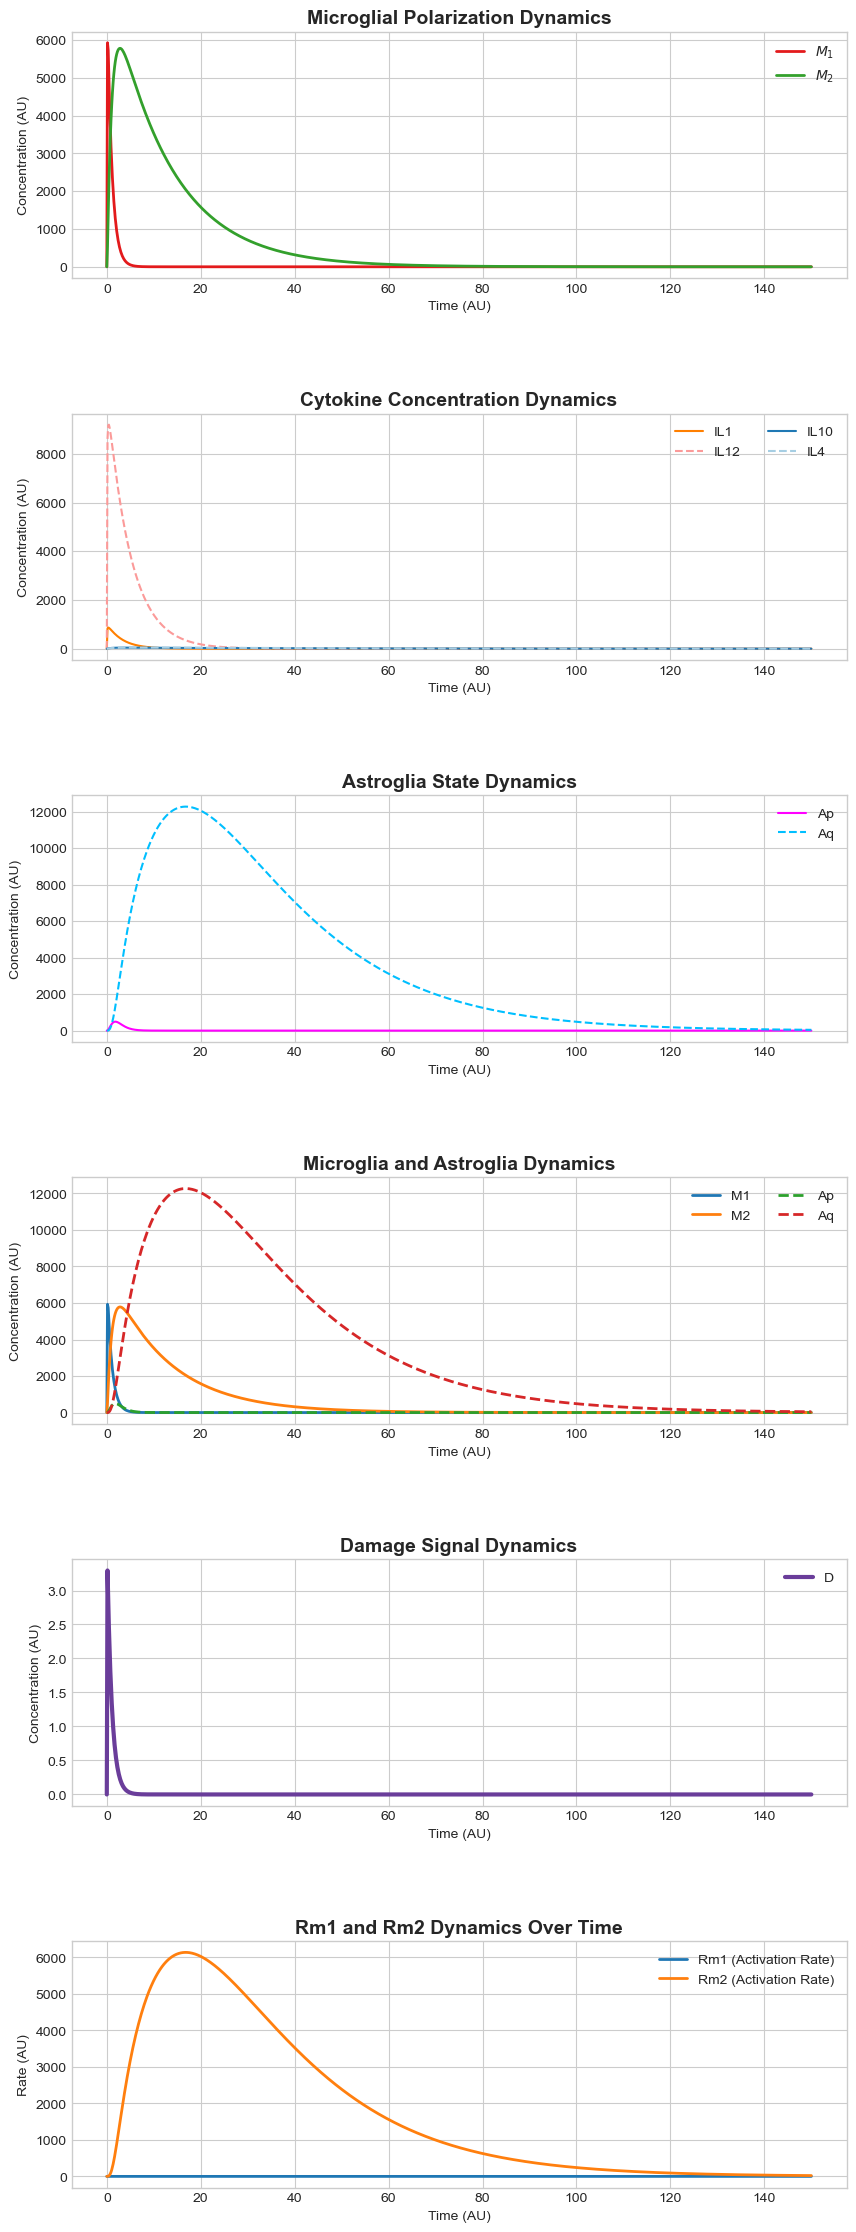

---

In [20]:
# ODE Systme Solution Graphs

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

# Check for Solution Data

if 'results_df' not in locals():
    display(Markdown("---"))
    display(Markdown("**Error:** The `results_df` DataFrame was not found."))
    display(Markdown("Please ensure the previous cell (Solver Integration) was run successfully."))
else:
    display(Markdown("## Simulation Results Visualization"))

    plt.style.use('seaborn-v0_8-whitegrid')

    Rm1_values = []
    Rm2_values = []

    for i in range(len(results_df)):
        M1 = results_df.loc[i, "M1"]
        M2 = results_df.loc[i, "M2"]
        IL1 = results_df.loc[i, "IL1"]
        IL12 = results_df.loc[i, "IL12"]
        IL10 = results_df.loc[i, "IL10"]
        IL4 = results_df.loc[i, "IL4"]
        Aq = results_df.loc[i, "Aq"]
        Ap = results_df.loc[i, "Ap"]

        Rm1 = calculate_rm1(
            IL1, IL12, IL4, IL10, Ap, Aq,
            b_n=params['b_n'],
            x_n=params['x_n'],
            a_inf1=params['a_inf1'],
            k_n1=params['k_n1'],
            k_n12=params['k_n12'],
            beta_Ap_M1=params['beta_Ap_M1'],
            beta_Aq_inhib_M1=params['beta_Aq_inhib_M1']
        )

        Rm2 = calculate_rm2(
            IL4, IL10, Aq,
            y_n=params['y_n'],
            z_n=params['z_n'],
            k_n4=params['k_n4'],
            k_n10=params['k_n10'],
            beta_Aq_M2=params['beta_Aq_M2']
        )

        Rm1_values.append(Rm1)
        Rm2_values.append(Rm2)

    results_df["Rm1"] = Rm1_values
    results_df["Rm2"] = Rm2_values

    fig, axes = plt.subplots(6, 1, figsize=(10, 28))
    fig.subplots_adjust(hspace=0.55)

    # --- Plot 1: Microglial Polarization (M1 & M2) ---
    ax = axes[0]
    ax.plot(results_df['Time'], results_df['M1'], label=r'$M_1$', color='#E31A1C', linewidth=2)
    ax.plot(results_df['Time'], results_df['M2'], label=r'$M_2$', color='#33A02C', linewidth=2)
    ax.set_title('Microglial Polarization Dynamics', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Concentration (AU)')
    ax.legend()

    # --- Plot 2: Cytokines ---
    ax = axes[1]
    ax.plot(results_df['Time'], results_df['IL1'], label='IL1', color='#FF7F00')
    ax.plot(results_df['Time'], results_df['IL12'], label='IL12', color='#FB9A99', linestyle='--')
    ax.plot(results_df['Time'], results_df['IL10'], label='IL10', color='#1F78B4')
    ax.plot(results_df['Time'], results_df['IL4'], label='IL4', color='#A6CEE3', linestyle='--')
    ax.set_title('Cytokine Concentration Dynamics', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Concentration (AU)')
    ax.legend(ncol=2)

    # --- Plot 3: Astroglial Polarization (Ap, Aq) ---
    ax = axes[2]
    ax.plot(results_df['Time'], results_df['Ap'], label='Ap', color='#FF00FF')
    ax.plot(results_df['Time'], results_df['Aq'], label='Aq', color='#00BFFF', linestyle='--')
    ax.set_title('Astroglia State Dynamics', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Concentration (AU)')
    ax.legend()

    # --- Plot 4: Combined M1 + M2 + Astroglia ---
    ax = axes[3]
    ax.plot(results_df['Time'], results_df['M1'], label='M1', linewidth=2)
    ax.plot(results_df['Time'], results_df['M2'], label='M2', linewidth=2)
    ax.plot(results_df['Time'], results_df['Ap'], label='Ap', linestyle='--', linewidth=2)
    ax.plot(results_df['Time'], results_df['Aq'], label='Aq', linestyle='--', linewidth=2)
    ax.set_title('Microglia and Astroglia Dynamics', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Concentration (AU)')
    ax.legend(ncol=2)

    # --- Plot 5: Damage Signal Dynamics ---
    ax = axes[4]
    ax.plot(results_df['Time'], results_df['D'], label='D', color='#6A3D9A', linewidth=3)
    ax.set_title('Damage Signal Dynamics', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Concentration (AU)')
    ax.legend()

    # --- Plot 6: Rm1 and Rm2 Dynamics ---
    ax = axes[5]
    ax.plot(results_df['Time'], results_df['Rm1'], label='Rm1 (Activation Rate)', linewidth=2)
    ax.plot(results_df['Time'], results_df['Rm2'], label='Rm2 (Activation Rate)', linewidth=2)
    ax.set_title('Rm1 and Rm2 Dynamics Over Time', fontsize=14, weight='bold')
    ax.set_xlabel('Time (AU)'); ax.set_ylabel('Rate (AU)')
    ax.legend()

    plt.show()

display(Markdown("---"))

## Euler Simulation of Microglial Polarization - Restricted Model
- Utilizes sample parameter values as temporary sensitivity analysis sources
- Euler integration manipulation for controled simulation

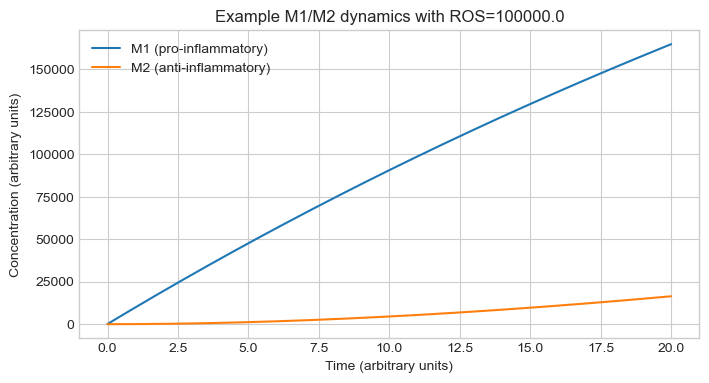

In [21]:
import matplotlib.pyplot as plt

Rm1, Rm2 = 0.10, 0.10
mr = 1.0
Rms = 0.01
mu_M1, mu_M2 = 0.01, 0.01

try:
    ROS, p_ros, i_ros
except NameError:
    ROS = 2.0; p_ros = 1.0; i_ros = 10.0

# Initial conditions
M1, M2 = 0.10, 0.10
dt = 0.01
n_steps = 2000

time = []
M1_trace = []
M2_trace = []

for step in range(n_steps):
    dM1 = calculate_dM1_dt(Rm1, mr, Rms, M1, None, None, None, mu_M1, ROS=ROS, p_ros=p_ros)
    dM2 = calculate_dM2_dt(Rm2, mr, Rms, M1, M2, None, mu_M2, ROS=ROS, i_ros=i_ros)

    M1 += dt * dM1
    M2 += dt * dM2

    # variable non-negativity restrictions
    M1 = max(M1, 0.0)
    M2 = max(M2, 0.0)

    time.append(step * dt)
    M1_trace.append(M1)
    M2_trace.append(M2)

plt.figure(figsize=(8,4))
plt.plot(time, M1_trace, label='M1 (pro-inflammatory)')
plt.plot(time, M2_trace, label='M2 (anti-inflammatory)')
plt.xlabel('Time (arbitrary units)')
plt.ylabel('Concentration (arbitrary units)')
plt.legend()
plt.title(f'Example M1/M2 dynamics with ROS={ROS}')
plt.show()